In [1]:
# ============================================================
# Instalación de librerías
# ============================================================

!pip install --quiet pyeph

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.7 MB/s eta 0:00:00


In [2]:
# ============================================================
# Importación de librerías
# ============================================================

# ------------------------------------------------------------
# Manejo de datos
# ------------------------------------------------------------
import pandas as pd
import numpy as np
from pyeph.get.microdata import NonExistentDBError

# ------------------------------------------------------------
# Visualización
# ------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Estadística descriptiva
# ------------------------------------------------------------
from scipy.stats import skew, kurtosis

# ------------------------------------------------------------
# Encuesta Permanente de Hogares (EPH)
# ------------------------------------------------------------
import pyeph

In [3]:
# ============================================================
# Descarga silenciosa EPH + Cálculo de NE por período
# 2004T1 .. 2024T4
# ============================================================

# ------------------------------------------------------------
# Descarga silenciosa con fallback de encoding
# ------------------------------------------------------------

def obtener_con_autoencoding(*, data, ano, periodo, tipo_base):
    """
    Intenta pyeph.obtener sin encoding (UTF-8 por defecto) y,
    si falla por UnicodeDecodeError, prueba latin1 y cp1252 (si la firma lo acepta).
    Silenciosa: no imprime. Devuelve DataFrame o None.
    """
    # 1) intento por defecto
    try:
        return pyeph.obtener(data=data, ano=ano, periodo=periodo, tipo_base=tipo_base)
    except NonExistentDBError:
        return None
    except UnicodeDecodeError:
        pass
    except TypeError:
        pass
    except Exception:
        pass

    # 2) reintentos con encoding alternativo (si la función lo acepta)
    for enc in ("latin1", "cp1252"):
        try:
            return pyeph.obtener(
                data=data, ano=ano, periodo=periodo, tipo_base=tipo_base, encoding=enc
            )
        except NonExistentDBError:
            return None
        except UnicodeDecodeError:
            continue
        except TypeError:
            continue
        except Exception:
            continue

    return None

# Conocidos como inexistentes en INDEC / EPH
MISSING = {(2007, 3), (2015, 3), (2015, 4), (2016, 1)}

bases_individuales = {}
bases_hogar = {}

for año in range(2004, 2025):      # 2004..2024 inclusive
    for trimestre in range(1, 5):  # T1..T4
        if (año, trimestre) in MISSING:
            continue

        clave = f"{año}T{trimestre}"

        df_i = obtener_con_autoencoding(
            data="eph", ano=año, periodo=trimestre, tipo_base="individual"
        )
        if df_i is not None:
            bases_individuales[clave] = df_i

        df_h = obtener_con_autoencoding(
            data="eph", ano=año, periodo=trimestre, tipo_base="hogar"
        )
        if df_h is not None:
            bases_hogar[clave] = df_h


Obtenido con exito: base_individual_2004T1.zip 

Obtenido con exito: base_hogar_2004T1.zip 

Obtenido con exito: base_individual_2004T2.zip 

Obtenido con exito: base_hogar_2004T2.zip 

Obtenido con exito: base_individual_2004T3.zip 

Obtenido con exito: base_hogar_2004T3.zip 

Obtenido con exito: base_individual_2004T4.zip 

Obtenido con exito: base_hogar_2004T4.zip 

Obtenido con exito: base_individual_2005T1.zip 

Obtenido con exito: base_hogar_2005T1.zip 

Obtenido con exito: base_individual_2005T2.zip 

Obtenido con exito: base_hogar_2005T2.zip 

Obtenido con exito: base_individual_2005T3.zip 

Obtenido con exito: base_hogar_2005T3.zip 

Obtenido con exito: base_individual_2005T4.zip 

Obtenido con exito: base_hogar_2005T4.zip 

Obtenido con exito: base_individual_2006T1.zip 

Obtenido con exito: base_hogar_2006T1.zip 

Obtenido con exito: base_individual_2006T2.zip 

Obtenido con exito: base_hogar_2006T2.zip 

Obtenido con exito: base_individual_2006T3.zip 

Obtenido con exito: 

In [4]:
# ------------------------------------------------------------
# Construcción de NE por período (función robusta y silenciosa)
# ------------------------------------------------------------

def _s(df, col):
    return df[col] if col in df.columns else pd.Series(np.nan, index=df.index)

def construir_NE(df_ind, df_hogar):
    """
    Replica el pipeline 1:
      - HOGAR: reemplazo VII*==0→98, conversión a numérico y filtros en TODAS las vars de rangos_validos
      - INDIVIDUAL: limpieza y filtros
      - NE = IEAE_sum / IX_TOT, con recorte NE <= 1
    Devuelve: CODUSU, IEAE_sum, IX_TOT, NE
    """
    if 'CODUSU' not in df_ind.columns or 'CODUSU' not in df_hogar.columns:
        return pd.DataFrame(columns=['CODUSU', 'IEAE_sum', 'IX_TOT', 'NE'])

    df_ind = df_ind.copy()
    df_hogar = df_hogar.copy()

    # ===== HOGAR =====
    # variables según tu pipeline 1
    variables_vii = ['VII1_1','VII1_2','VII2_1','VII2_2','VII2_3','VII2_4']
    if 'IPCF' in df_hogar.columns:
        df_hogar['IPCF'] = pd.to_numeric(df_hogar['IPCF'].astype(str).str.replace(",", "."), errors='coerce')

    # Reemplazo 0 -> 98 en VII* (igual que en el pipeline 1)
    for v in variables_vii:
        if v in df_hogar.columns:
            df_hogar[v] = df_hogar[v].replace(0, 98)

    # Conversión general a numérico (excepto CODUSU)
    for col in df_hogar.columns:
        if col != 'CODUSU':
            df_hogar[col] = pd.to_numeric(df_hogar[col], errors='coerce')

    # Mismo set de rangos que usaste en el script 1
    rangos_validos_hogar = {
        'IV1': (1, 5), 'IV2': (1, 10), 'IV3': (1, 3), 'IV4': (1, 9), 'IV5': (1, 2),
        'IV6': (1, 3), 'IV7': (1, 3), 'IV8': (1, 2), 'IV9': (1, 3), 'IV10': (1, 3), 'IV11': (1, 4),
        'IV12_1': (1, 2), 'IV12_2': (1, 2), 'IV12_3': (1, 2),
        'II1': (1, 10), 'II2': (1, 10), 'II3': (1, 2), 'II4_1': (1, 2), 'II4_2': (1, 2), 'II4_3': (1, 2),
        'II7': (1, 8), 'II8': (1, 3), 'II9': (1, 4),
        'V1': (1, 2), 'V2': (1, 2), 'V7': (1, 2), 'V8': (1, 2), 'V9': (1, 2), 'V10': (1, 2),
        'V19_A': (1, 2), 'V19_B': (1, 2),
        'IX_TOT': (1, 20), 'IPCF': (0, 5000001),
        'VII1_1': (1, 50), 'VII1_2': (1, 50), 'VII2_1': (1, 50), 'VII2_2': (1, 50),
        'VII2_3': (1, 50), 'VII2_4': (1, 50)
    }
    valores_extras_vii = [96, 97, 98]

    for var, (lo, hi) in rangos_validos_hogar.items():
        if var in df_hogar.columns:
            if var in variables_vii:
                df_hogar = df_hogar[df_hogar[var].isin(list(range(lo, hi + 1)) + valores_extras_vii)]
            else:
                df_hogar = df_hogar[(df_hogar[var] >= lo) & (df_hogar[var] <= hi)]

    # ===== INDIVIDUAL =====
    if 'CH11' in df_ind.columns:
        df_ind['CH11'] = df_ind['CH11'].replace(0, 9)
    if 'CH12' in df_ind.columns:
        df_ind['CH12'] = df_ind['CH12'].replace(0, 1)

    rangos_validos_ind = {
        'COMPONENTE': (1, 20), 'CH04': (1, 2), 'CH06': (0, 105),
        'CH07': (1, 5), 'CH08': [1, 2, 3, 4, 9, 12, 13, 23, 123],
        'CH09': (1, 3), 'CH10': (1, 3), 'CH11': [1, 2, 9],
        'CH12': (1, 9), 'CH13': (0, 2), 'NIVEL_ED': (1, 7),
        'ESTADO': (1, 4), 'CAT_OCUP': (0, 4), 'CAT_INAC': (0, 7)
    }
    for var, criterio in rangos_validos_ind.items():
        if var in df_ind.columns:
            if isinstance(criterio, tuple):
                df_ind = df_ind[(pd.to_numeric(df_ind[var], errors='coerce') >= criterio[0]) &
                                (pd.to_numeric(df_ind[var], errors='coerce') <= criterio[1])]
            else:
                df_ind = df_ind[pd.to_numeric(df_ind[var], errors='coerce').isin(criterio)]

    # Educación
    df_ind['CH14'] = pd.to_numeric(_s(df_ind, 'CH14'), errors='coerce')
    df_ind['EDA_ESC'] = np.nan
    CH10 = _s(df_ind, 'CH10'); CH12 = _s(df_ind, 'CH12'); CH13 = _s(df_ind, 'CH13'); CH06 = _s(df_ind, 'CH06')

    c1 = (CH10 == 1); c21 = (CH10 == 2) & (CH13 == 1); c22 = (CH10 == 2) & (CH13 == 2)

    # CH10==1
    df_ind.loc[c1 & (CH12 == 1), 'EDA_ESC'] = df_ind['CH14']
    df_ind.loc[c1 & (CH12 == 2), 'EDA_ESC'] = df_ind['CH14'] + 5
    df_ind.loc[c1 & (CH12.isin([3, 4])), 'EDA_ESC'] = df_ind['CH14'] + 12
    df_ind.loc[c1 & (CH12 == 5), 'EDA_ESC'] = df_ind['CH14'] + 14
    df_ind.loc[c1 & (CH12.isin([6, 7])), 'EDA_ESC'] = df_ind['CH14'] + 17
    df_ind.loc[c1 & (CH12 == 8), 'EDA_ESC'] = df_ind['CH14'] + 21
    df_ind.loc[c1 & (CH12 == 9), 'EDA_ESC'] = 23

    # CH10==2 y CH13==1
    df_ind.loc[c21 & (CH12 == 1), 'EDA_ESC'] = 5
    df_ind.loc[c21 & (CH12 == 2), 'EDA_ESC'] = 12
    df_ind.loc[c21 & (CH12 == 3), 'EDA_ESC'] = 14
    df_ind.loc[c21 & (CH12.isin([4, 5])), 'EDA_ESC'] = 17
    df_ind.loc[c21 & (CH12 == 6), 'EDA_ESC'] = 19
    df_ind.loc[c21 & (CH12 == 7), 'EDA_ESC'] = 21
    df_ind.loc[c21 & (CH12.isin([8, 9])), 'EDA_ESC'] = 23

    # CH10==2 y CH13==2
    df_ind.loc[c22 & (CH12 == 1), 'EDA_ESC'] = df_ind['CH14']
    df_ind.loc[c22 & (CH12 == 2), 'EDA_ESC'] = df_ind['CH14'] + 5
    df_ind.loc[c22 & (CH12.isin([3, 4])), 'EDA_ESC'] = df_ind['CH14'] + 12
    df_ind.loc[c22 & (CH12 == 5), 'EDA_ESC'] = df_ind['CH14'] + 14
    df_ind.loc[c22 & (CH12.isin([6, 7])), 'EDA_ESC'] = df_ind['CH14'] + 17
    df_ind.loc[c22 & (CH12 == 8), 'EDA_ESC'] = df_ind['CH14'] + 21
    df_ind.loc[c22 & (CH12 == 9), 'EDA_ESC'] = 23

    # Reglas especiales
    df_ind.loc[CH06.between(2, 6), 'EDA_ESC'] = CH06
    df_ind.loc[(CH10 == 3) & (CH06 >= 7), 'EDA_ESC'] = 0

    # EDA_ESP e IEAE
    df_ind['EDA_ESP'] = np.select([CH06.between(0, 1), CH06.between(2, 23), CH06 >= 24], [1, CH06, 23], default=np.nan)
    df_ind['IEAE'] = (df_ind['EDA_ESC'] / df_ind['EDA_ESP']).clip(upper=1)

    # ===== Merge y NE =====
    df_ind_agg = df_ind.groupby('CODUSU', as_index=False).agg(IEAE_sum=('IEAE', 'sum'))
    df_modelo = df_hogar.merge(df_ind_agg, on='CODUSU', how='inner')

    if 'IX_TOT' in df_modelo.columns:
        ix = pd.to_numeric(df_modelo['IX_TOT'], errors='coerce')
    else:
        ix = pd.Series(np.nan, index=df_modelo.index)

    df_modelo['NE'] = df_modelo['IEAE_sum'] / ix.replace(0, np.nan)

    # Recorte NE <= 1 (como en el pipeline 1)
    df_modelo = df_modelo[df_modelo['NE'] <= 1].copy()

    out = df_modelo[['CODUSU', 'IEAE_sum']].copy()
    out['IX_TOT'] = ix.loc[df_modelo.index]
    out['NE'] = df_modelo['NE']
    return out

# ------------------------------------------------------------
# Ejecutar para TODOS los períodos descargados
# ------------------------------------------------------------
df_modelo_por_periodo = {}
registros = []

claves = sorted(set(bases_individuales.keys()) & set(bases_hogar.keys()))

for clave in claves:
    df_ind = bases_individuales[clave]
    df_hog = bases_hogar[clave]

    df_m = construir_NE(df_ind, df_hog)

    # metadatos de período
    try:
        anio_str, trim_str = clave.split('T')
        anio = int(anio_str)
        trimestre = int(trim_str)
    except Exception:
        anio = np.nan
        trimestre = np.nan

    df_m = df_m.assign(anio=anio, trimestre=trimestre, clave=clave)

    df_modelo_por_periodo[clave] = df_m
    registros.append(df_m)

# Panel con todos los períodos
df_NE_panel = (
    pd.concat(registros, ignore_index=True)
    if registros
    else pd.DataFrame(columns=['CODUSU','IEAE_sum','IX_TOT','NE','anio','trimestre','clave'])
)

# Serie agregada por período (promedio no ponderado)
df_NE_serie = df_NE_panel.groupby(['anio','trimestre','clave'], as_index=False)['NE'].mean()

# (Opcional) comprobar 2024T4 explícitamente
prom_2024T4 = df_NE_panel.loc[df_NE_panel['clave']=='2024T4', 'NE'].mean()

/tmp/ipython-input-938786068.py:11: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  pi = pd.PeriodIndex(year=df_NE_serie['anio'], quarter=df_NE_serie['trimestre'], freq='Q-DEC')


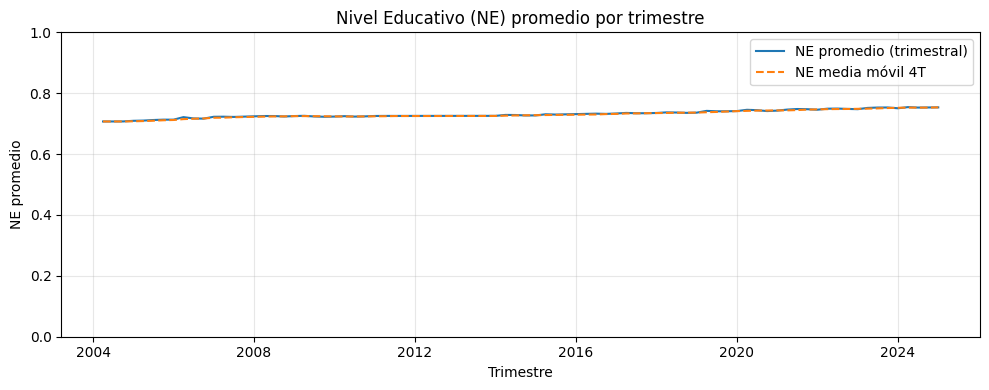

In [5]:
# ============================================================
# Serie temporal: NE promedio por trimestre (toda la historia)
# Usa df_NE_serie con columnas: anio, trimestre, clave, NE
# ============================================================

# Asegurar tipos y crear índice trimestral
df_NE_serie['anio'] = pd.to_numeric(df_NE_serie['anio'], errors='coerce').astype('Int64')
df_NE_serie['trimestre'] = pd.to_numeric(df_NE_serie['trimestre'], errors='coerce').astype('Int64')

# Construir PeriodIndex trimestral (Q-DEC: T1=Mar, T2=Jun, T3=Sep, T4=Dic)
pi = pd.PeriodIndex(year=df_NE_serie['anio'], quarter=df_NE_serie['trimestre'], freq='Q-DEC')
df_NE_serie['fecha'] = pi.to_timestamp(how='end')  # fin de trimestre

# Ordenar y dejar columnas útiles
serie_NE = (df_NE_serie
            .sort_values('fecha')
            .loc[:, ['fecha', 'anio', 'trimestre', 'clave', 'NE']]
            .reset_index(drop=True))

# (Opcional) media móvil 4T
serie_NE['NE_mm4'] = serie_NE['NE'].rolling(4, min_periods=1).mean()

# Ver una muestra
# display(serie_NE.head())

# ------------------------------------------------------------
# Gráfico
# ------------------------------------------------------------
plt.figure(figsize=(10,4))
plt.plot(serie_NE['fecha'], serie_NE['NE'], label='NE promedio (trimestral)')
plt.plot(serie_NE['fecha'], serie_NE['NE_mm4'], linestyle='--', label='NE media móvil 4T')
plt.title('Nivel Educativo (NE) promedio por trimestre')
plt.xlabel('Trimestre')
plt.ylabel('NE promedio')
plt.ylim(0, 1)  # NE está entre 0 y 1 (tras el recorte)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# (Opcional) Exportar a Excel/CSV
# ------------------------------------------------------------
# serie_NE.to_excel('serie_NE_trimestral.xlsx', index=False)
# serie_NE.to_csv('serie_NE_trimestral.csv', index=False)

In [6]:
df_NE_serie

,anio,trimestre,clave,NE,fecha
0,2004,1,2004T1,0.707127,2004-03-31 23:59:59.999999999
1,2004,2,2004T2,0.707168,2004-06-30 23:59:59.999999999
2,2004,3,2004T3,0.707309,2004-09-30 23:59:59.999999999
3,2004,4,2004T4,0.709369,2004-12-31 23:59:59.999999999
4,2005,1,2005T1,0.710072,2005-03-31 23:59:59.999999999
...,...,...,...,...,...
65,2023,4,2023T4,0.750569,2023-12-31 23:59:59.999999999
66,2024,1,2024T1,0.754280,2024-03-31 23:59:59.999999999
67,2024,2,2024T2,0.752843,2024-06-30 23:59:59.999999999
68,2024,3,2024T3,0.753175,2024-09-30 23:59:59.999999999


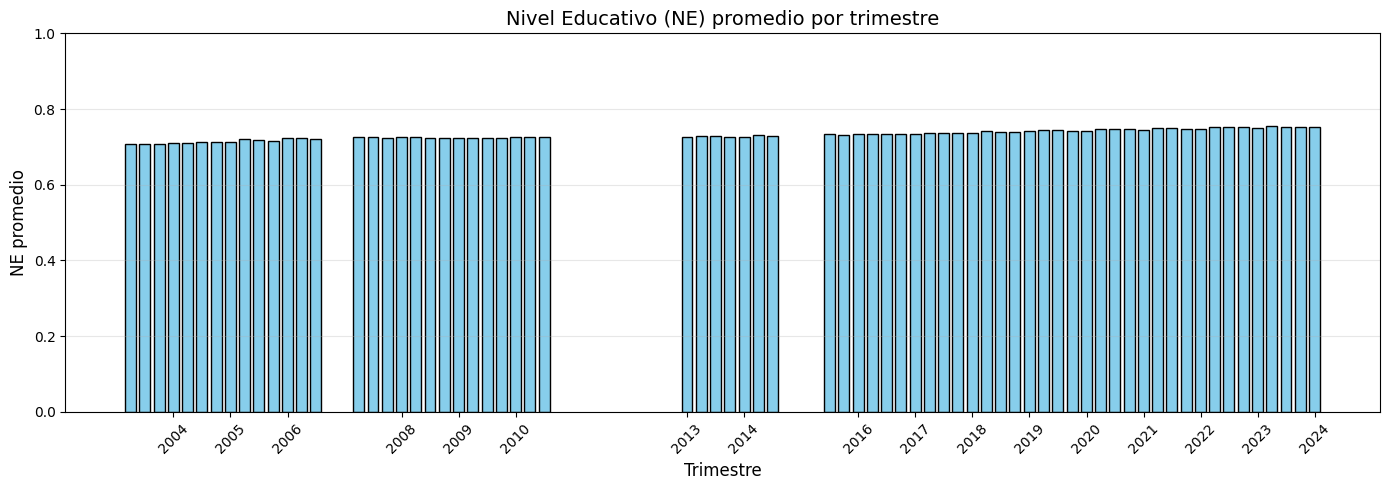

In [7]:
# ============================================================
# Gráfico de barras: NE promedio por trimestre
# ============================================================

plt.figure(figsize=(14,5))
plt.bar(serie_NE['fecha'], serie_NE['NE'], width=70, color='skyblue', edgecolor='k')

plt.title('Nivel Educativo (NE) promedio por trimestre', fontsize=14)
plt.xlabel('Trimestre', fontsize=12)
plt.ylabel('NE promedio', fontsize=12)
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

# Etiquetas de año en el eje x (cada 4 trimestres)
xticks = serie_NE[serie_NE['trimestre'] == 4]['fecha']
xlabels = serie_NE[serie_NE['trimestre'] == 4]['anio'].astype(str)
plt.xticks(xticks, xlabels, rotation=45)

plt.tight_layout()
plt.show()


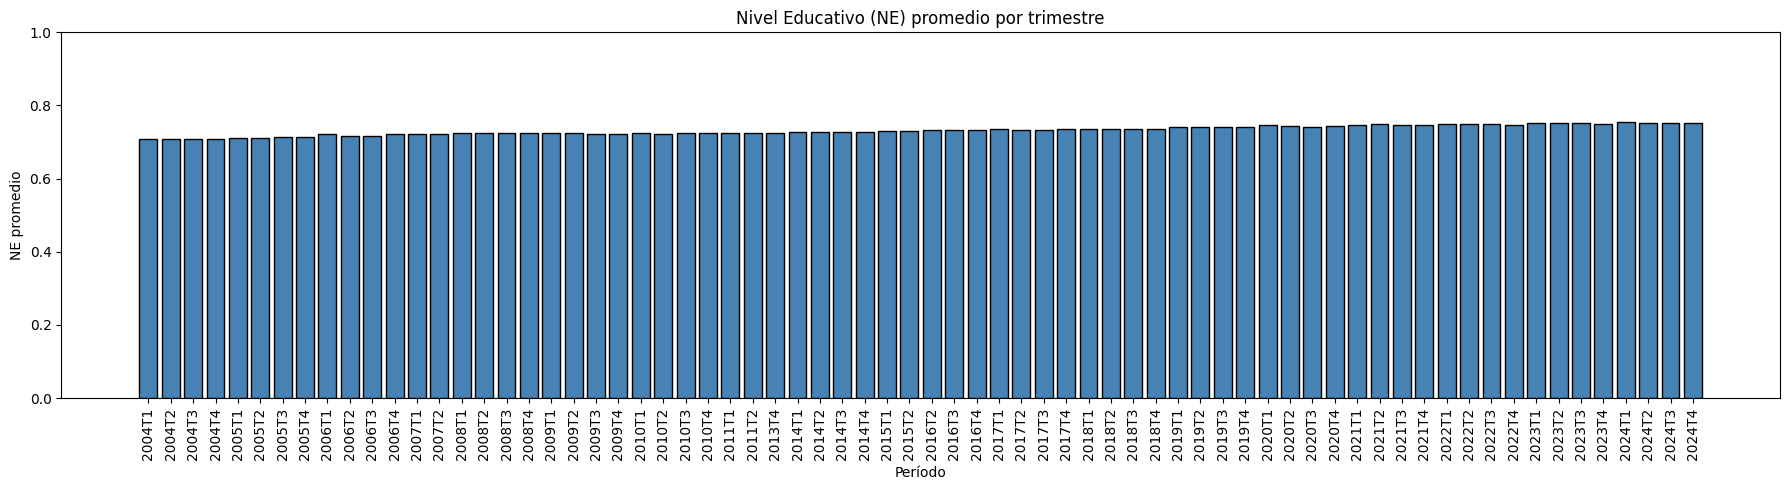

In [8]:
plt.figure(figsize=(18,5))
plt.bar(serie_NE['clave'], serie_NE['NE'], color='steelblue', edgecolor='k')
plt.title('Nivel Educativo (NE) promedio por trimestre')
plt.xlabel('Período')
plt.ylabel('NE promedio')
plt.ylim(0,1)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


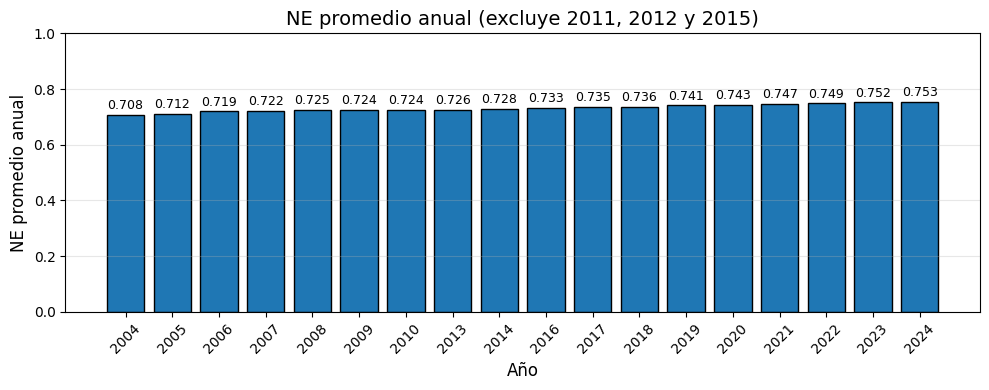

In [9]:
# ============================================================
# Promedios anuales (excluye 2011, 2012 y 2015) + gráfico de barras
# ============================================================

# 1) Calcular promedio anual (promedio simple de los trimestres disponibles por año)
anios_excluir = {2011, 2012, 2015}
serie_NE_anual = (
    serie_NE[~serie_NE['anio'].isin(anios_excluir)]
    .groupby('anio', as_index=False)['NE']
    .mean()
    .rename(columns={'NE': 'NE_prom_anual'})
    .sort_values('anio')
)

# 2) Gráfico de barras
plt.figure(figsize=(10,4))
plt.bar(serie_NE_anual['anio'].astype(str), serie_NE_anual['NE_prom_anual'], edgecolor='k')
plt.title('NE promedio anual (excluye 2011, 2012 y 2015)', fontsize=14)
plt.xlabel('Año', fontsize=12)
plt.ylabel('NE promedio anual', fontsize=12)
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)

# (Opcional) Anotar valores sobre cada barra
for x, y in zip(serie_NE_anual['anio'].astype(str), serie_NE_anual['NE_prom_anual']):
    plt.text(x, y + 0.01, f"{y:.3f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# (Opcional) Exportar
serie_NE_anual.to_excel('NE_promedio_anual.xlsx', index=False)


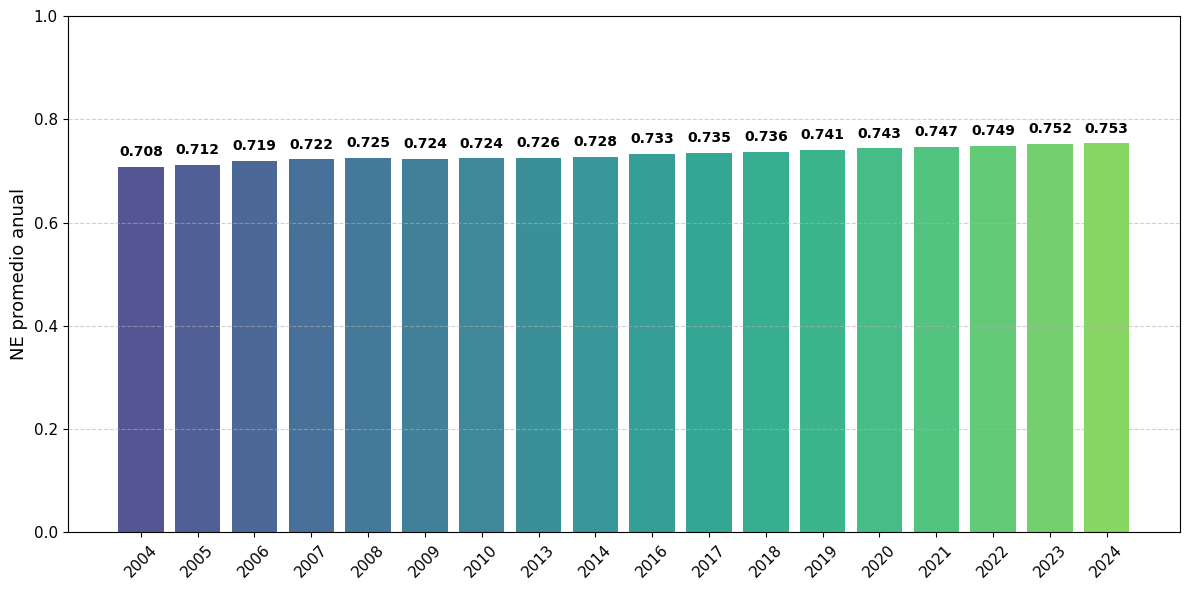

In [11]:
# ============================================================
# Gráfico de barras mejorado: NE promedio anual
# ============================================================

plt.figure(figsize=(12,6))
bars = plt.bar(
    serie_NE_anual['anio'].astype(str),
    serie_NE_anual['NE_prom_anual'],
    color=plt.cm.viridis(np.linspace(0.2, 0.8, len(serie_NE_anual))),
    edgecolor='none',
    alpha=0.9
)

# Títulos y etiquetas
plt.title('', fontsize=16, weight='bold') #Nivel Educativo (NE) promedio anual\n(excluye 2011, 2012 y 2015)
plt.xlabel('', fontsize=13)
plt.ylabel('NE promedio anual', fontsize=13)

# Ejes y límites
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Etiquetas de eje X
plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)

# Anotar valores sobre cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.015,
        f"{height:.3f}",
        ha='center', va='bottom',
        fontsize=10, weight='bold'
    )

plt.tight_layout()
plt.savefig("NE_serie_anual.png", dpi=600, bbox_inches='tight')
plt.show()
